# PHYS 481 Assignment 2: Images and Filters

### Group 19
### Authors: Pete Rossi, Spencer Mung, Carl Aquino


### Question 1

Load the file 'mandrill.png' using matplotlib and perform some basic manipulations on it. For each of these, display the original and the altered image side-by-side with no rescaling of the pixel size.

a. Create a 10-pixel wide vertical black line through the middle of the image by replacing data values in the image with zeroes. Display the original and the altered image side-by-side.

b. Transpose the original image. Display the original and the altered image side-by-side.
    
c. "Posterize" the original image by reducing the number of different color levels in each channel from 256 to 2. In other words, reduce the precision in the data values in each color channel (R,G,B) so they assume only the value 0 or 1, and no values in between. Display the original and the altered image side-by-side.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# Helper function for this assignment
def display_img(img1,img2=None):
    """
    Display 1 or 2 RGB or RGBA images in matplotlib format side-by-side inline in Jupyter.
    For 1 image, call with only one parameter.
    Disable any resizing of the images; show them at the exact resolution of the image without rescaling the pixel size.
    """
    dpi = matplotlib.rcParams['figure.dpi']  # dots per inch of the device
    height = img1.shape[0]
    width = img1.shape[1]
    if img2 is None:   # Only one figure provided
        figsize = width / float(dpi), height / float(dpi)
        plt.figure(figsize=figsize)
        plt.imshow(img1)
    else:                # 2 Figures provided
        height=np.max([height,img2.shape[0]])
        width=width+img2.shape[1]
        figsize = width / float(dpi), height / float(dpi)
        f, ax=plt.subplots(1,2,figsize=figsize)
        ax[0].imshow(img1)
        ax[1].imshow(img2)


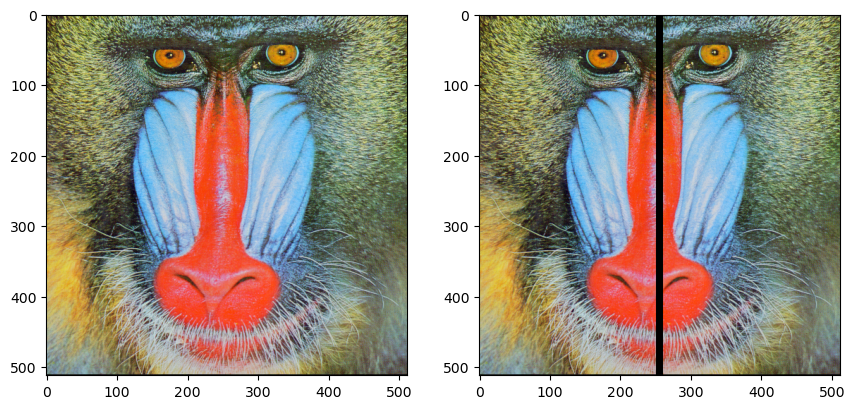

In [27]:
def q1a(image):
    """
    docstring goes here
    """
    mod_img = image.copy()  # make copy of image to display beside original
    row_len, col_len, _ = mod_img.shape  # extract dimensions from image


    # we want middle 10 columns to be blacked out
    middle_index = col_len//2   # subtract 1 as we want to zero index our length
    upper_index = middle_index + 5
    lower_index = middle_index - 5
    replacement_pixel = np.array([0,0,0,1])  # black pixel to replace colour with a zero value

    for row in range(row_len):
        mod_img[row][lower_index:upper_index] = replacement_pixel

    # now display original image beside altered image
    display_img(image, mod_img)

img_mandrill = plt.imread("mandrill.png")
q1a(img_mandrill)

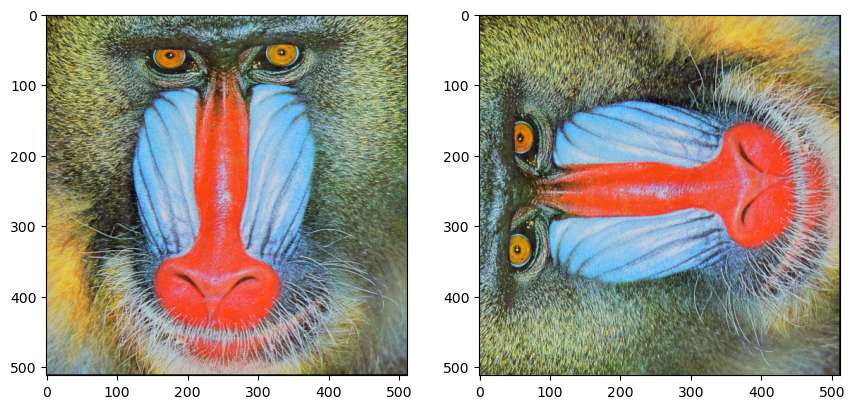

In [3]:
def q1b(image):
    """
    transpose the image
    """
    mod_img = np.transpose(image, (1,0,2))

    # now display original image beside altered image
    display_img(image, mod_img)
    
q1b(img_mandrill)

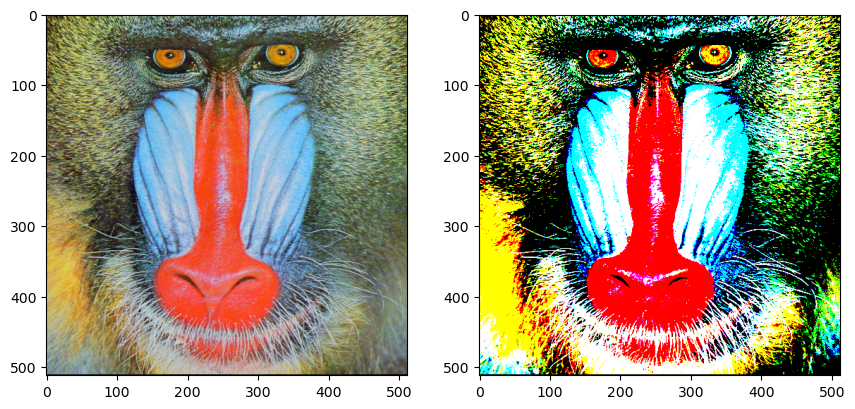

In [29]:
def q1c(image):
    """
    Posterizing original image so that each channel only can have a value of 0 or 1
    """
    mod_img = image.copy()
    row_len, col_len, chan_len = mod_img.shape
    max_channel_value = 1
    # max_channel_value = 256

    for row in range(row_len):
        for col in range(col_len):
            for chan in range(chan_len - 1):  # remove one from channel length so we don't change the alpha value
                chan_value = mod_img[row][col][chan]
                if  chan_value < (max_channel_value/2):
                    mod_img[row][col][chan] = 0
                else:
                    mod_img[row][col][chan] = 1

    # now display original image beside altered image
    display_img(image, mod_img)

q1c(img_mandrill)


---------

### Question 2

To rotate an $n$-row, $m$-column image by an angle $\theta$ in the anticlockwise direction, pixel location $[i,j]$ in the rotated (new) image corresponds to pixel location $[x,y]$ in the original image, where

$$ x = (i-n/2)\cos(\theta)+(j-m/2)\sin(\theta)+n/2 $$

$$ y= -(i-n/2)\sin(\theta)+(j-m/2)\cos(\theta)+m/2 $$

With a few notes:

1. If $[x,y]$ falls outside the range of the original image (which happens on the edges of the rotated image), a fill color should used. Please use black for this assignment.
2. The values of $x$ and $y$ will generally be non-integer, so this rotation requires evaluation of the image data at locations that are not exactly on pixel centers in the original image. In other words, some sort of interpolation scheme is required. For this assignment, please simply round to the nearest integer. This is known as "nearest neighbor" interpolation. Bi-linear interpolation or other interpolation schemes are also sometimes used, but just take the simple nearest neighbor for this assignment.

a. Load the mandrill image and rotate it 20 degrees anticlockwise using the equations above implemented in a nested loop. Include all the calculations (even the trig functions) in the loop. Time the execution using %timeit. Plot the original and rotated images.

b. Repeat question 2a, but pull the trig functions and anything else you can pre-calculate outside the loops and rotate the original image 20 degrees clockwise.

c. Repeat question 2b but use Just-In-Time compilation to rotate 30 degrees anticlockwise.

d. Prepare a table of how long each method took. In a few sentences, comment on the speed of the various methods.



2.65 s ± 33 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


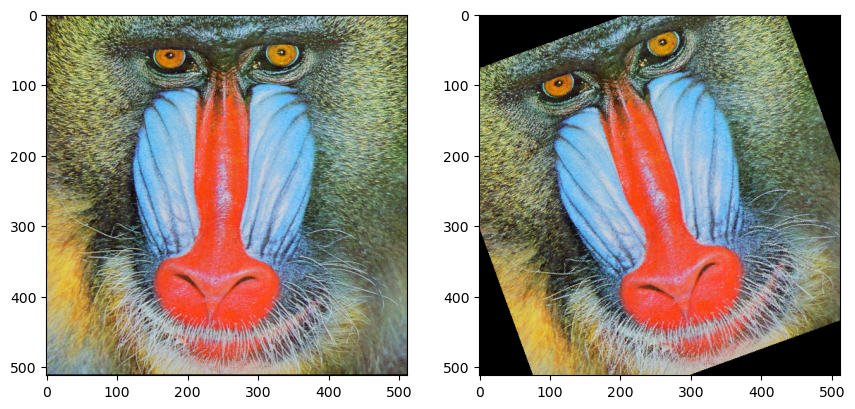

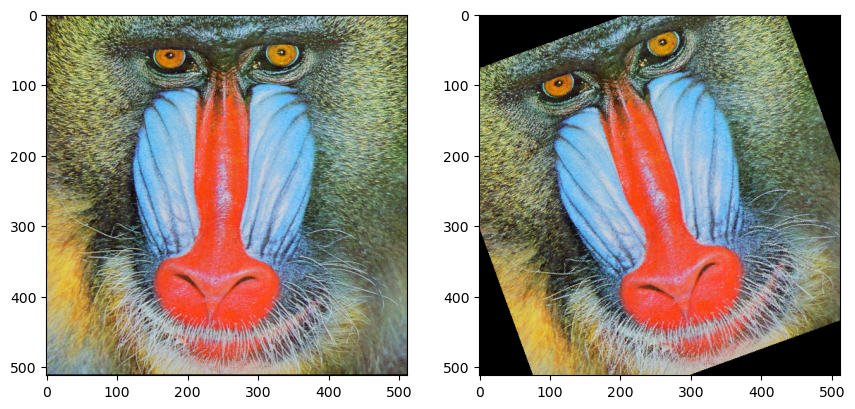

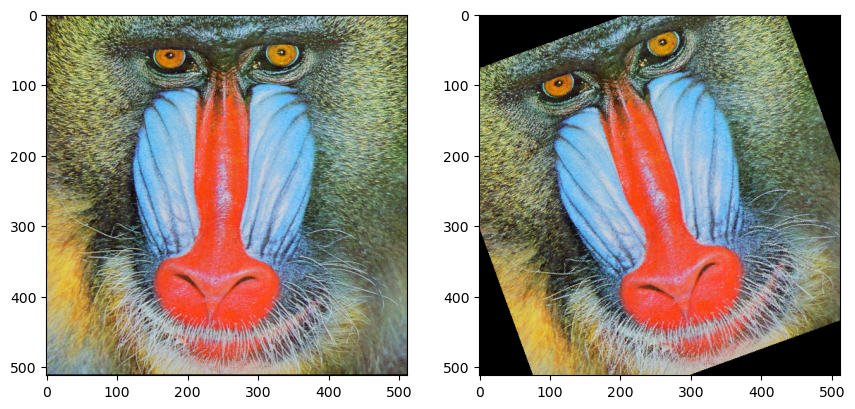

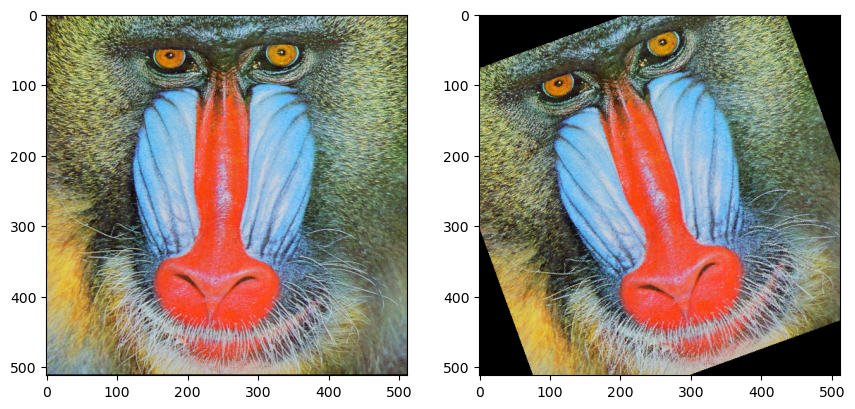

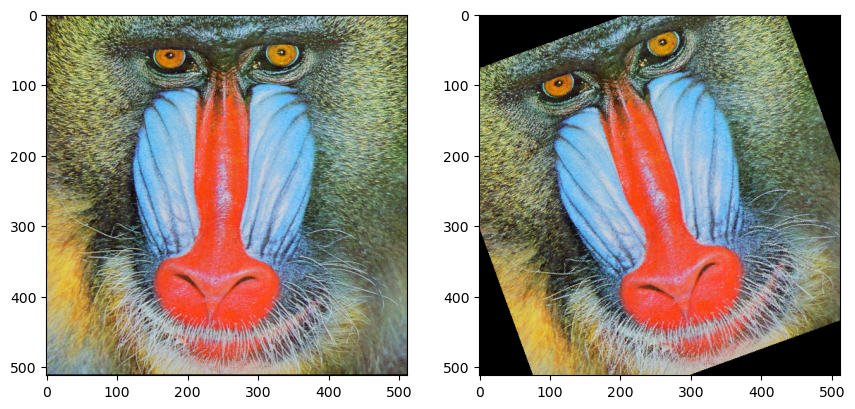

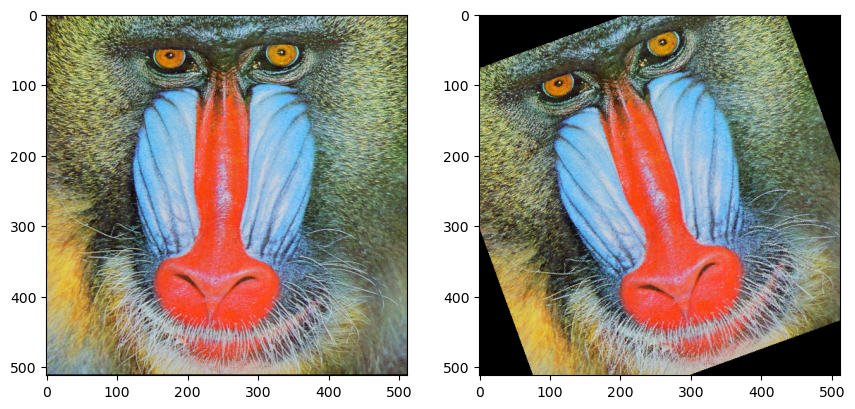

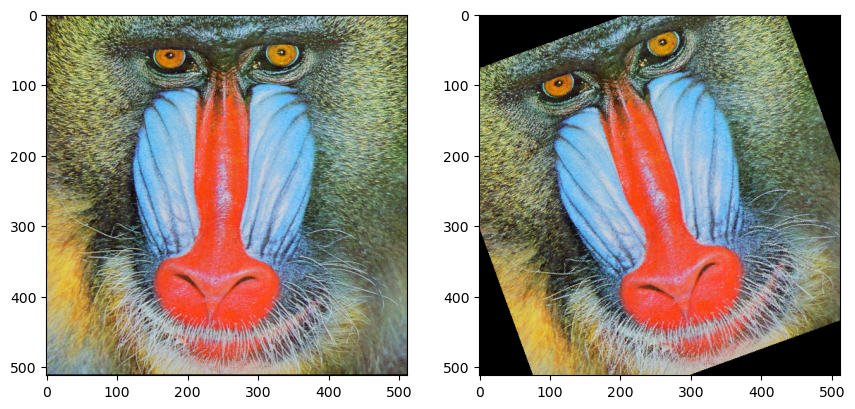

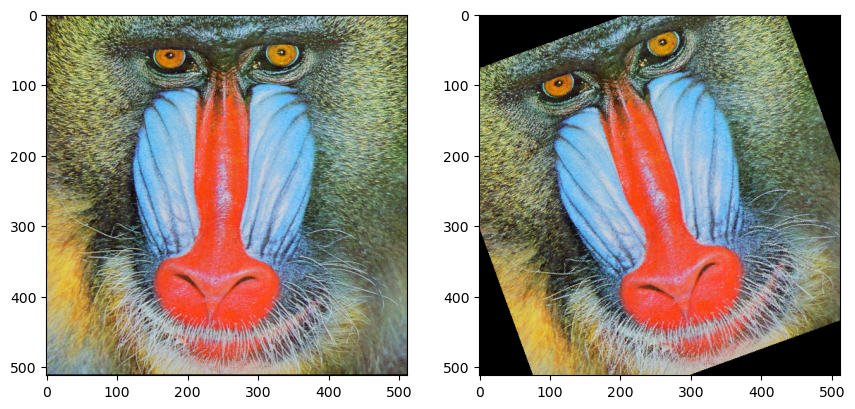

In [55]:
# Question 2a
def q2a(image):
    """
    To avoid artifacting, we loop over each pixel in the new image and calculate where it should have been in the
    original image
    """
    # black pixel value to be used to fill values that fall outside of image after rotation
    black_pixel = np.array([0,0,0,1])
    mod_img = np.full_like(image, black_pixel)

    # get image size
    row_len, col_len, _ = mod_img.shape

    for row in range(row_len):
        angle_of_rotation = np.pi/9  # angle of rotation is 20 degrees in radians
        for col in range(col_len):
            row_rot, col_rot = rotated_coordinates(row, col, angle_of_rotation, row_len, col_len)

            # if the rotated coordinates are in our original image, set the modified pixel at row, col to the pixel
            # associated with the rotated coordinates
            if (row_rot in range(row_len)) and (col_rot in range(col_len)):
                mod_img[row][col] = image[row_rot][col_rot]


    # now display original image beside altered image
    display_img(image, mod_img)

def rotated_coordinates(i, j, theta, n, m):
    x = ((i - (n/2))*np.cos(theta)) + (j - (m/2))*np.sin(theta) + (n/2)
    y = (-(i - (n/2))*np.sin(theta)) + (j - (m/2))*np.cos(theta) + (m/2)
    return int(np.round(x)), int(np.round(y))


%timeit q2a(img_mandrill)


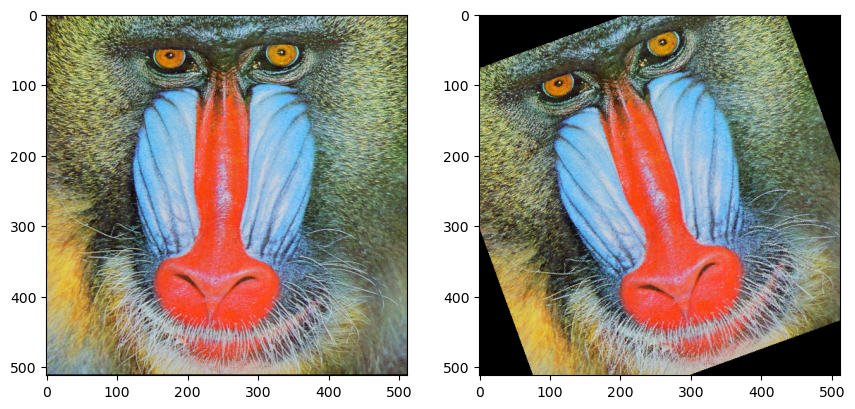

In [56]:
# Question 2b
def q2b(image):
    """
    To avoid artifacting, we loop over each pixel in the new image and calculate where it should have been in the
    original image
    """
    # black pixel value to be used to fill values that fall outside of image after rotation
    black_pixel = np.array([0,0,0,1])
    mod_img = np.full_like(image, black_pixel)

    # get image size
    row_len, col_len, _ = mod_img.shape
    angle_of_rotation = np.pi/9  # angle of rotation is 20 degrees in radians

    # precalculated trig functions
    sin_theta = np.sin(angle_of_rotation)
    cos_theta = np.cos(angle_of_rotation)

    # precalculated row/col lengths
    n_half = row_len/2
    m_half = col_len/2

    def fast_rotated_coordinates(i, j):
        x = ((i - n_half) * cos_theta) + (j - m_half) * sin_theta + n_half
        y = (-(i - n_half) * sin_theta) + (j - m_half) * cos_theta + m_half
        return int(np.round(x)), int(np.round(y))

    for row in range(row_len):
        for col in range(col_len):
            row_rot, col_rot = fast_rotated_coordinates(row, col)
            # if the rotated coordinates are in our original image, set the modified pixel at row, col to the pixel
            # associated with the rotated coordinates
            if (row_rot in range(row_len)) and (col_rot in range(col_len)):
                mod_img[row][col] = image[row_rot][col_rot]


    # now display original image beside altered image
    display_img(image, mod_img)


q2b(img_mandrill)


In [7]:
from numba import jit

@jit(nopython=True)
def rotate_nested_loops_JIT(img,angle):
    """
    docstring goes here
    """


# Question 2c
    



ModuleNotFoundError: No module named 'numba'

Table and comments for question 2d go here. You can use Markdown for tables like this:

| Method | Time Taken (seconds) | Comments |
|--------|----------------------|----------|
| Nested Loops |  |  |
| Optimized Loops |  | |
| JIT Compilation |  |  |

-------

### Question 3

Image arrays can be usefully filtered by 2D centered FIR (Finite Impulse Response) filters:

$$ y'_{i,j}=\sum_{m=-m_1}^{m_1}\sum_{n=-n_1}^{n_1}a_{m,n}y_{i,j}$$

These filters can perform many different functions including blurring, sharpening and edge detection. The coefficient array $a_{m,n}$ is known as the filter "kernel", and has size $2m_1+1$ by $2n_1+1$. Filter kernels are usually square, with $m_1=n_1$. This filtering operation is known as 2D convolution.

Edge detection is usually accomplished by smoothing (to remove image noise) and then applying a derivative operator. Further nonlinear operations can be used to refine the edges by suppressing weak edges, joining strong edges, etc. A commonly-used derivative kernel is the Sobel operator. For the horizontal (x) derivative, the Sobel operator is:

$$ S_x= \left[ \begin{array}{ccc}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1 \end{array} \right]  $$

and the vertical derivative uses the transpose $S_y=S_x^T$. These are simple extensions of the 1D 3-point stencil derivative operator from last week. The gradient magnitude of array $A$ is then $G=\sqrt{(S_x * A)^2+(S_y * A)^2}$ where the $*$ symbol denotes 2D convolution and the square root is taken on each element of the array individually.

Another commonly used filter kernel is the Laplacian ($\nabla^2$) kernel

$$ L = \left[ \begin{array}{ccc}
0 & 1 & 0 \\
1 & -4 & 1 \\
0 & 1 & 0 \end{array} \right]  $$

which detects second derivatives. This is sometimes used in image sharpening filters, which take the form

$$ K = \left[ \begin{array}{ccc}
0 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 0 \end{array} \right] - \alpha L$$

where the degree of sharpening can be controlled by $\alpha$.

Start by writing a general function to apply an arbitrary filter (2D convolution) of the type described above, and then answer the following questions. Your function may discard the edge points where the filter cannot be applied ($m_1$ points from each of the 2 edges in the first dimension and $n_1$ from the 2 edges in the second dimension).

a. Load the mandrill image again, and perform a "boxcar smoothing" with a 15x15 kernel of the form $a_{m,n}=1/15^2$. Display the original and smoothed images.

b. Load the "peppers.png" image and apply a 5x5 boxcar smoothing. Find the gradient magnitude $G$ using the Sobel operator on each channel (R,G,B) and sum them to get an overall gradient. Apply a threshold of 30% of the maximum gradient to discard weak edges (that is, if the gradient is less than 30% of the max, set the RGB values to 0,0,0 and otherwise set R,G,B=1,1,1). Plot the original image and the processed edges.

c. Load the "eye.png" image and apply a Laplacian sharpening filter with kernel $K$ as given above and $\alpha=0.3$ (moderate sharpening) and then with $\alpha=3.0$ (extreme sharpening). This filter may cause some of the RGB values to go outside their nominal [0,1] range; they should be clipped to constrain the range. Plot the original image and the sharpened image for both values of $\alpha$.


In [ ]:
def convolve_2d(img,kernel):
    """
    docstring
    """


# Load the image
img = plt.imread('mandrill.png')

# do stuff for 3a

In [ ]:
# Q3b

In [ ]:
#Q3c

## Submission

Gradescope has difficulties with Jupyter notebooks larger than 1 MB. For this assignment, your notebook will almost certainly be larger than 1 MB, so please submit your work as a PDF file instead. To create a PDF from your Jupyter notebook:
1.	If you’re using a JupyterLab environment (like syzygy), try selecting File -> “Save and Export Notebook As…”->PDF.
2.	If you’re using Visual Studio Code, click the “…” (More Actions) at the top of the file editing window (beside “Outline”) and select “Export” and then “PDF”.
3.	If you’re using Google Colab, use File->Print and then Print to PDF.  If that doesn’t work, try the cell below.
4.	If you encounter trouble with exporting your PDF (which is not uncommon on many platforms), log into ucalgary.syzygy.ca, upload your .ipynb file and follow step 1.



## Image sources

Mandrill.png and peppers.png are standard test images from the USC Signal and Image Processing Institute available at  https://sipi.usc.edu/database/database.php?volume=misc .

eyes.png is from the Wikipedia page for unsharp masking and is available at https://commons.wikimedia.org/wiki/File:Unsharped_eye.jpg. Image author is Ru_dragon, and the image is distributed under the GNU Free Documentation License.



In [ ]:
# For Google colab users: If you have trouble exporting your notebook to PDF, uncomment and run this
# cell to install the necessary packages and convert your notebook to PDF.
# Replace the filename "Untitled0.ipynb" in the last line with the correct filename you used.
# You may need to run it twice.

# !apt-get install texlive texlive-xetex texlive-latex-extra pandoc
# !pip install pypandoc
# !jupyter nbconvert --to PDF "/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb"